# 03 - Baseline Fraud Classification Model

**Project:** Credit card fraud prediction MVP.

**What this notebook does:** trains a first, untuned classifier that estimates the
probability a transaction is fraud, and measures how good it is with metrics that
make sense for a rare event.

This is the MVP model. Default settings, no grid search, one simple choice for
each decision. The point is a correct end-to-end pipeline (features -> split ->
train -> honest evaluation -> saved model), not a competition score. Places to
improve later are marked `TODO(refine)`.


## 1. Load the deduped data and build features

Input is `data/processed/transactions_deduped.parquet` from
`02_data_wrangling.ipynb`. Feature construction lives in `features.py` at the
repo root so the Streamlit app builds inputs the exact same way.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
sys.path.insert(0, str(REPO_ROOT))

from features import (
    build_features,
    FEATURE_COLUMNS,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    BOOLEAN_FEATURES,
    TARGET,
)

PROCESSED = REPO_ROOT / "data" / "processed" / "transactions_deduped.parquet"
if not PROCESSED.exists():
    raise FileNotFoundError(f"{PROCESSED} not found. Run notebooks 01 then 02 first.")

df = pd.read_parquet(PROCESSED)
print(f"{len(df):,} transactions, fraud rate {df[TARGET].mean():.3%}")


743,588 transactions, fraud rate 1.571%


In [2]:
X = build_features(df)
y = df[TARGET].astype(int)
print("Feature matrix:", X.shape)
X.dtypes.to_frame("dtype")


Feature matrix: (743588, 21)


,dtype
transactionAmount,float64
creditLimit,int64
availableMoney,float64
currentBalance,float64
hour,int32
dayofweek,int32
month,int32
accountAgeDays,int64
daysSinceAddressChange,int64
amountToCreditLimit,float64


### What each feature is

- **Money:** `transactionAmount`, `creditLimit`, `availableMoney`,
  `currentBalance`, and three ratios of the transaction and balances to the
  credit limit. The ratios let the model see "this is a big charge *for this
  account*" rather than just a big number.
- **Timing:** `hour`, `dayofweek`, `month` pulled from the timestamp.
- **Account history:** `accountAgeDays` and `daysSinceAddressChange`. A charge
  soon after an address change is a classic fraud tell.
- **Card checks:** `cvvMismatch` (entered CVV does not match the card),
  `cardPresent` (chip or swipe vs. online/phone), `expirationDateKeyInMatch`.
- **Categories:** `transactionType`, `merchantCategoryCode`, `posEntryMode`,
  `posConditionCode`, `acqCountry`, `merchantCountryCode`. Blank values are
  turned into their own `"missing"` category.

Dropped: the six all-blank columns, and the account/card number fields, which are
identifiers, not signal. `merchantName` (about 2,500 values) is left out of the
MVP. `TODO(refine): add merchantName back with target encoding.`


## 2. Train / validation / test split

- **Test set (20%)** is held out and only touched once, at the end.
- The remaining 80% is split again into **train (60% of all)** and
  **validation (20% of all)**. Validation is used to pick a decision threshold
  without peeking at the test set.

Every split is **stratified** on `isFraud` so the ~1.6% fraud rate is preserved
in each part.


In [3]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

for name, yy in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:<11} {len(yy):>8,} rows   fraud {yy.mean():.3%}   ({int(yy.sum()):,} fraud)")


train        446,152 rows   fraud 1.571%   (7,011 fraud)
validation   148,718 rows   fraud 1.571%   (2,337 fraud)
test         148,718 rows   fraud 1.571%   (2,337 fraud)


## 3. The model

**Algorithm: XGBoost (gradient-boosted trees).** For tabular data with a mix of
numeric and categorical fields it is a strong default: it trains fast, captures
interactions, gives a feature-importance readout, and saves to a small file
(under 1 MB here, versus hundreds of MB for a comparable random forest, which
matters for deploying the Streamlit app). Random Forest is the other obvious
choice; comparing them properly is left for later.
`TODO(refine): benchmark a Random Forest.`

**Class imbalance: `scale_pos_weight`.** Fraud is ~1.6% of rows, so a model that
always predicts "not fraud" is 98% accurate and useless. `scale_pos_weight` is
set to the ratio of legitimate to fraud rows in the training data, which tells
the booster to weight each fraud error about 60 times as heavily as a legitimate
one. The other standard option is **SMOTE** (synthetic oversampling of the
minority class); `TODO(refine): compare SMOTE against scale_pos_weight.`

**Everything else is left at XGBoost's defaults** (100 trees, depth 6, learning
rate 0.3). No grid search yet. `TODO(refine): tune with cross-validation.`

**Preprocessing:** one-hot encode the six categorical columns, pass everything
else through untouched (trees do not need scaling).


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier


def make_pipeline(scale_pos_weight: float) -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ],
        remainder="passthrough",  # numeric columns (booleans are already 0/1)
    )
    model = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
    )
    return Pipeline([("preprocess", preprocess), ("model", model)])


spw_train = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (train) = {spw_train:.1f}")

pipe = make_pipeline(spw_train)
pipe.fit(X_train, y_train)
print("Trained on", f"{len(X_train):,}", "rows.")


scale_pos_weight (train) = 62.6


Trained on 446,152 rows.


## 4. Evaluation

**Accuracy is deliberately not reported.** With 1.6% fraud, accuracy is dominated
by the easy negatives. The metrics that matter here:

- **PR-AUC (average precision):** area under the precision-recall curve. Sums up
  performance across every possible threshold, focused on the positive (fraud)
  class. The no-skill value equals the fraud rate.
- **ROC-AUC:** probability the model ranks a random fraud above a random
  legitimate transaction. 0.5 is random, 1.0 is perfect.
- **Precision, recall, F1** at a chosen decision threshold.


In [5]:
from sklearn.metrics import average_precision_score, roc_auc_score

test_proba = pipe.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, test_proba)
roc_auc = roc_auc_score(y_test, test_proba)
no_skill = y_test.mean()

print(f"PR-AUC (average precision) : {pr_auc:.4f}")
print(f"  no-skill baseline        : {no_skill:.4f}   (predicting the fraud rate)")
print(f"  lift over no-skill       : {pr_auc / no_skill:.1f}x")
print(f"ROC-AUC                    : {roc_auc:.4f}")


PR-AUC (average precision) : 0.0623
  no-skill baseline        : 0.0157   (predicting the fraud rate)
  lift over no-skill       : 4.0x
ROC-AUC                    : 0.7809


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

def report_at(threshold, proba, y_true, label):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"--- {label} (threshold = {threshold:.3f}) ---")
    print(f"precision {precision_score(y_true, pred, zero_division=0):.3f}   "
          f"recall {recall_score(y_true, pred, zero_division=0):.3f}   "
          f"F1 {f1_score(y_true, pred, zero_division=0):.3f}")
    print(f"caught {tp:,} of {tp + fn:,} frauds; {fp:,} false alarms on "
          f"{tn + fp:,} legit transactions")
    return pred

_ = report_at(0.50, test_proba, y_test, "Default threshold")


--- Default threshold (threshold = 0.500) ---
precision 0.044   recall 0.617   F1 0.082
caught 1,443 of 2,337 frauds; 31,485 false alarms on 146,381 legit transactions


At the default 0.5 threshold the model flags far too much. `scale_pos_weight`
pushes fraud scores up hard, so a 0.5 cut catches a large share of fraud but
buries it under tens of thousands of false alarms. The default cut is the wrong
operating point; the threshold needs to move up.


In [7]:
# Pick the threshold that maximises F1 on the VALIDATION set, then apply it to
# the untouched test set. The test set is not used to choose anything.
from sklearn.metrics import precision_recall_curve

val_proba = pipe.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.nanargmax(f1_curve[:-1]))   # last point has no threshold
chosen_threshold = float(thr[best_i])
print(f"Chosen threshold (max F1 on validation): {chosen_threshold:.3f}")
print(f"  validation P {prec[best_i]:.3f}  R {rec[best_i]:.3f}  F1 {f1_curve[best_i]:.3f}")


Chosen threshold (max F1 on validation): 0.792
  validation P 0.092  R 0.206  F1 0.127


In [8]:
test_pred = report_at(chosen_threshold, test_proba, y_test, "Validation-tuned threshold")
print()
print(classification_report(y_test, test_pred, digits=4, zero_division=0))


--- Validation-tuned threshold (threshold = 0.792) ---
precision 0.090   recall 0.200   F1 0.124
caught 467 of 2,337 frauds; 4,739 false alarms on 146,381 legit transactions



              precision    recall  f1-score   support

           0     0.9870    0.9676    0.9772    146381
           1     0.0897    0.1998    0.1238      2337

    accuracy                         0.9556    148718
   macro avg     0.5383    0.5837    0.5505    148718
weighted avg     0.9729    0.9556    0.9638    148718



### Reading the result

- The model has **real signal**: PR-AUC is roughly four times the no-skill
  baseline and ROC-AUC is around 0.78, meaning it ranks most frauds above most
  legitimate transactions.
- **Turned into a yes/no call, it is still weak.** At the tuned threshold it
  catches about a fifth of fraud while raising several thousand false alarms. The
  0.5 default instead catches most fraud but with precision near 4%. Neither is
  production-ready. That is a normal first pass on this dataset with no tuning and
  no merchant-level features.
- The right threshold in practice depends on the cost of a missed fraud versus
  the cost of reviewing a false alarm. That trade-off is a business input, not a
  modelling constant. `TODO(refine): choose the threshold from a cost matrix.`


## 5. Which features mattered

XGBoost importances (by gain) show how much each feature improved the model's
splits. They show influence, not direction.


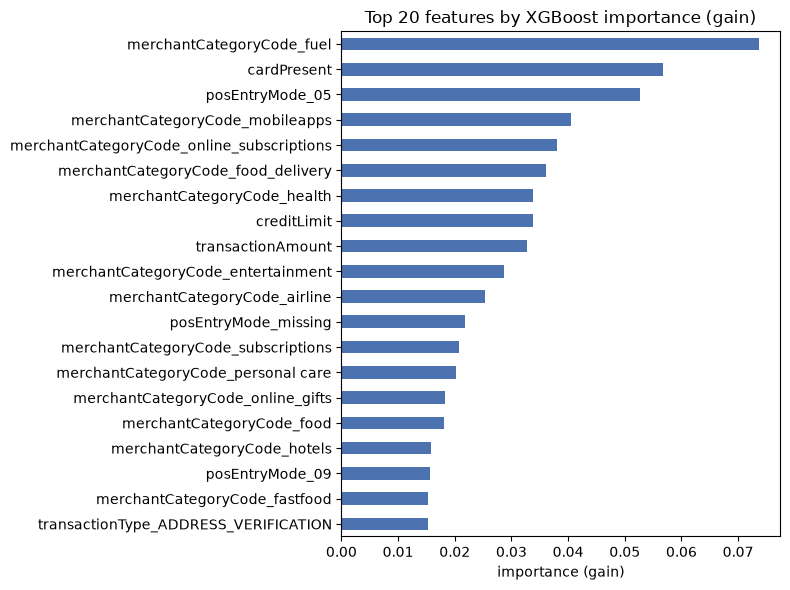

,importance
merchantCategoryCode_fuel,0.0737
cardPresent,0.0568
posEntryMode_05,0.0527
merchantCategoryCode_mobileapps,0.0405
merchantCategoryCode_online_subscriptions,0.0381
merchantCategoryCode_food_delivery,0.0361
merchantCategoryCode_health,0.0338
creditLimit,0.0338
transactionAmount,0.0327
merchantCategoryCode_entertainment,0.0287


In [9]:
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES)) + NUMERIC_FEATURES + BOOLEAN_FEATURES
importances = pd.Series(pipe.named_steps["model"].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 20 features by XGBoost importance (gain)")
ax.set_xlabel("importance (gain)")
fig.tight_layout()
plt.show()
top.round(4).to_frame("importance")


**In plain terms.** The strongest single signals are the **merchant
category** (fuel, mobile apps, online subscriptions, food delivery and a few
others each carry weight), whether the **card was physically present**, and **how
the card was entered** (`posEntryMode`). That matches the EDA finding that fraud
skews toward card-not-present transactions and certain categories. The
**credit limit** and **transaction amount** also matter. Influence is spread
across many features rather than concentrated in one, which is why the model
beats any simple rule but is still not sharp.


## 6. Save the model

Refit the pipeline on the **full 80% training portion** (train + validation) so
the saved model uses as much data as possible, then bundle it with the chosen
threshold, the feature list, and the test metrics. `app.py` loads this file.


In [10]:
import joblib
import sklearn
import xgboost

spw_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
final_pipe = make_pipeline(spw_full)
final_pipe.fit(X_train_full, y_train_full)

bundle = {
    "pipeline": final_pipe,
    "threshold": chosen_threshold,
    "feature_columns": FEATURE_COLUMNS,
    "target": TARGET,
    "metrics_on_test": {
        "pr_auc": round(float(pr_auc), 4),
        "roc_auc": round(float(roc_auc), 4),
        "no_skill_pr_auc": round(float(no_skill), 4),
        "precision": round(float(precision_score(y_test, test_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_test, test_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_test, test_pred, zero_division=0)), 4),
    },
    "trained_rows": int(len(X_train_full)),
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "model": "XGBClassifier(defaults, scale_pos_weight=%.1f)" % spw_full,
}

MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "fraud_model_v1.pkl"
joblib.dump(bundle, MODEL_PATH)
print(f"Saved {MODEL_PATH.relative_to(REPO_ROOT)}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
bundle["metrics_on_test"]


Saved models\fraud_model_v1.pkl  (0.4 MB)


{'pr_auc': 0.0623,
 'roc_auc': 0.7809,
 'no_skill_pr_auc': 0.0157,
 'precision': 0.0897,
 'recall': 0.1998,
 'f1': 0.1238}

In [11]:
# Sanity check: reload and predict on a few rows.
reloaded = joblib.load(MODEL_PATH)
sample = df.sample(5, random_state=0)
sample_X = build_features(sample)
proba = reloaded["pipeline"].predict_proba(sample_X)[:, 1]
pd.DataFrame({
    "transactionAmount": sample["transactionAmount"].values,
    "merchantCategoryCode": sample["merchantCategoryCode"].values,
    "cardPresent": sample["cardPresent"].values,
    "actual_isFraud": sample[TARGET].values,
    "fraud_probability": proba.round(4),
    "flagged": (proba >= reloaded["threshold"]),
})


,transactionAmount,merchantCategoryCode,cardPresent,actual_isFraud,fraud_probability,flagged
0,618.65,online_retail,False,False,0.6843,False
1,25.11,fastfood,True,False,0.2300,False
2,274.65,rideshare,False,False,0.8029,True
3,167.91,personal care,True,False,0.1485,False
4,276.31,online_retail,False,False,0.8226,True


## Summary

- Built a first fraud classifier: engineered ~21 features, split the data with
  fraud stratification, trained a default **XGBoost** with `scale_pos_weight` for
  the class imbalance, and evaluated with **PR-AUC**, **ROC-AUC**, and
  precision/recall/F1 at a validation-chosen threshold. Accuracy was left out on
  purpose.
- **Result:** clear ranking signal (ROC-AUC ~0.78, PR-AUC about 4x the no-skill
  baseline), but weak as a hard yes/no flag without tuning.
- The most useful signals are merchant category, whether the card was present,
  how the card was entered, the credit limit, and the transaction amount.
- Model saved to `models/fraud_model_v1.pkl` for the Streamlit app.

**Future work (`TODO(refine)`):** benchmark a Random Forest; compare SMOTE vs.
`scale_pos_weight`; add `merchantName` via target encoding; tune hyperparameters
with cross-validation; set the decision threshold from a cost matrix instead
of F1.

**Next:** `app.py` - a small Streamlit demo that loads this model and shows the
fraud probability for a transaction.
